# Implied Volatility Analysis

This notebook validates the numerical inversion of Black–Scholes prices and uses the solver to recover a synthetic equity-style volatility skew across strikes and maturities.

The option prices below are deliberately generated from known volatilities. This provides a controlled test: a correct solver should recover the inputs to numerical precision before it is applied to external market data.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.derivatives import EuropeanCall, EuropeanPut
from src.implied_volatility import solve_implied_volatility
from src.yieldcurve import YieldCurve

## Recovery of a known volatility

A call and put are first priced using a known volatility of 27%. The solver then receives only the option price and contract inputs.

In [2]:
yield_curve = YieldCurve(
    maturities=[0.25, 0.5, 1.0, 2.0],
    zero_rates=[0.028, 0.030, 0.032, 0.035],
)

true_volatility = 0.27
contracts = {
    "Call": EuropeanCall(100, 105, 1.25, true_volatility, yield_curve),
    "Put": EuropeanPut(100, 95, 0.75, true_volatility, yield_curve),
}

recovery_rows = []
for name, contract in contracts.items():
    result = contract.implied_volatility(contract.price(), initial_guess=0.15)
    recovery_rows.append({
        "Contract": name,
        "Market price": contract.price(),
        "True volatility": true_volatility,
        "Recovered volatility": result.volatility,
        "Absolute error": abs(result.volatility - true_volatility),
        "Method": result.method,
        "Iterations": result.iterations,
    })

recovery = pd.DataFrame(recovery_rows)
recovery

,Contract,Market price,True volatility,Recovered volatility,Absolute error,Method,Iterations
0,Call,11.654424,0.27,0.27,4.440892e-16,newton,4
1,Put,5.831044,0.27,0.27,1.665335e-16,newton,5


The recovered values should be effectively identical to the original volatility. Newton–Raphson normally converges quickly when vega is well behaved; the implementation falls back to bisection when the Newton step is unreliable.

## Synthetic volatility skew

Black–Scholes assumes a single constant volatility for a given contract. Market option prices are commonly represented instead by an implied volatility that varies with strike and maturity.

The function below creates a controlled equity-style skew: lower strikes carry higher implied volatility, with mild curvature and a term-structure adjustment. These values are converted into option prices and then recovered by numerical inversion.

In [3]:
S0 = 100.0
strikes = np.arange(75.0, 130.0, 5.0)
maturities = [0.25, 0.5, 1.0, 2.0]


def synthetic_volatility(strike, maturity):
    log_moneyness = np.log(strike / S0)
    return (
        0.20
        - 0.16 * log_moneyness
        + 0.35 * log_moneyness**2
        + 0.015 * np.exp(-maturity)
    )


surface_rows = []
for maturity in maturities:
    for strike in strikes:
        input_volatility = synthetic_volatility(strike, maturity)
        market_price = EuropeanCall(
            S0, strike, maturity, input_volatility, yield_curve
        ).price()
        result = solve_implied_volatility(
            market_price,
            option_type="call",
            S0=S0,
            K=strike,
            T=maturity,
            yield_curve=yield_curve,
            initial_guess=0.20,
        )
        surface_rows.append({
            "Strike": strike,
            "Maturity": maturity,
            "Market price": market_price,
            "Input volatility": input_volatility,
            "Implied volatility": result.volatility,
            "Absolute error": abs(result.volatility - input_volatility),
            "Method": result.method,
        })

surface = pd.DataFrame(surface_rows)
surface.head(10)

,Strike,Maturity,Market price,Input volatility,Implied volatility,Absolute error,Method
0,75.0,0.25,25.613302,0.286677,0.286677,1.125766e-12,newton
1,80.0,0.25,20.754261,0.264813,0.264813,1.665335e-15,newton
2,85.0,0.25,16.033607,0.246929,0.246929,7.494005e-16,newton
3,90.0,0.25,11.601354,0.232425,0.232425,1.942890e-15,newton
4,95.0,0.25,7.690964,0.220810,0.220810,2.636780e-15,newton
5,100.0,0.25,4.563719,0.211682,0.211682,1.471046e-15,newton
6,105.0,0.25,2.377224,0.204709,0.204709,1.665335e-16,newton
7,110.0,0.25,1.076263,0.199612,0.199612,1.689204e-13,newton
8,115.0,0.25,0.424932,0.196157,0.196157,2.386980e-15,newton
9,120.0,0.25,0.148836,0.194145,0.194145,2.804090e-12,newton


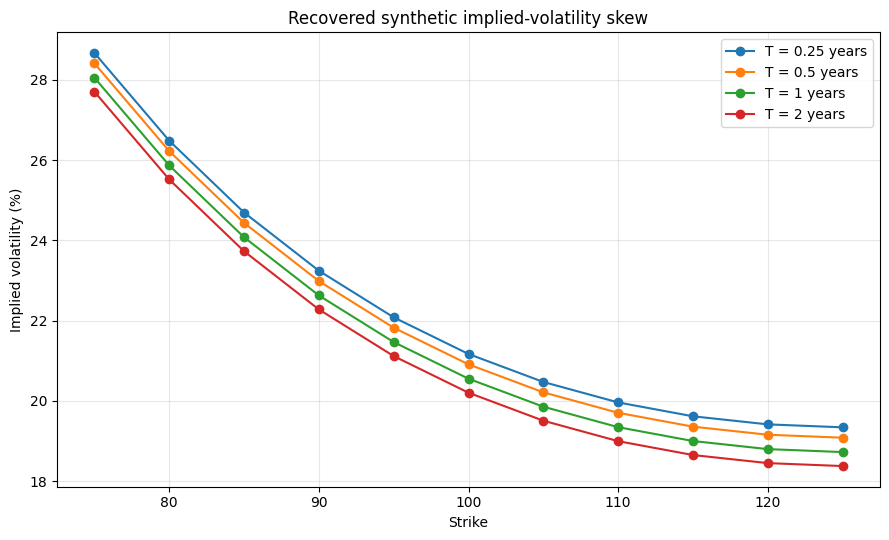

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for maturity, group in surface.groupby("Maturity"):
    ax.plot(
        group["Strike"],
        100 * group["Implied volatility"],
        marker="o",
        label=f"T = {maturity:g} years",
    )

ax.set_title("Recovered synthetic implied-volatility skew")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied volatility (%)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [5]:
validation_summary = pd.Series({
    "Maximum absolute volatility error": surface["Absolute error"].max(),
    "Mean absolute volatility error": surface["Absolute error"].mean(),
    "Newton solutions": int((surface["Method"] == "newton").sum()),
    "Bisection solutions": int((surface["Method"] == "bisection").sum()),
})
validation_summary

Maximum absolute volatility error    2.804090e-12
Mean absolute volatility error       1.240737e-13
Newton solutions                     4.400000e+01
Bisection solutions                  0.000000e+00
dtype: float64

## Interpretation

- Numerical inversion recovers the known input volatilities to near machine precision in this controlled setting.
- Lower-strike calls imply higher volatility in the synthetic equity-style skew.
- The term structure shifts the level of implied volatility without changing the core inversion method.
- Implied volatility is not a direct forecast produced by Black–Scholes. It is the volatility parameter required for the model to reproduce an observed option price.
- A real-data extension would replace the synthetic prices with cleaned bid–ask midpoints and would need to handle liquidity, stale quotes and arbitrage inconsistencies.

## No-arbitrage safeguards

Before solving, the implementation checks that a supplied European option price lies within its no-arbitrage bounds. It also requires the chosen volatility interval to bracket a solution. These checks prevent the numerical method from returning a plausible-looking volatility for an impossible price.

In [6]:
try:
    solve_implied_volatility(
        101.0,
        option_type="call",
        S0=100,
        K=100,
        T=1.0,
        yield_curve=yield_curve,
    )
except ValueError as error:
    print(error)

market_price=101 is above the no-arbitrage upper bound 100.
